# Notebook 10 — ML Model Evaluation & Traffic Flow Modeling

## Part A: ML Model Evaluation
Trains models to predict next-frame TTC from current kinematic features.
Evaluates with full diagnostic suite:
- RMSE, MAE, R²
- Reliability diagram
- Expected Calibration Error (ECE)
- Feature importance
- Error analysis (where does the model fail?)

## Part B: Traffic Flow Modeling
Fits Greenshields and Greenberg speed-density models to extract:
- Free-flow speed (v_f)
- Jam density (k_j)
- Capacity flow and critical density
- Traffic state classification (free flow / transitional / congested)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.waymo_loader import load_dataset, extract_trajectories
from src.metrics.safety_metrics import batch_ttc, nearest_agent_distances
from src.ml_eval.model_evaluation import (
    build_prediction_dataset, segment_train_test_split,
    train_and_evaluate, expected_calibration_error,
    reliability_diagram_data, error_analysis
)
from src.traffic.flow_model import (
    estimate_flow_variables, fit_fundamental_diagram,
    classify_traffic_state, plot_fundamental_diagram
)

sns.set_theme(style='whitegrid')

In [2]:
dataset = load_dataset('../data', max_segments=10)
trajectories = extract_trajectories(dataset['lidar_box'])
trajectories = nearest_agent_distances(trajectories)
ttc_df = batch_ttc(trajectories)
print(f'Loaded: {len(trajectories):,} trajectory rows, {ttc_df["near_miss"].sum()} near-miss frames')

Loaded: 108,693 trajectory rows, 1568 near-miss frames


/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: invalid value encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: divide by zero encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)


## Part A — TTC Prediction Model

In [3]:
print('Building prediction dataset...')
pred_df = build_prediction_dataset(trajectories, ttc_df, horizon_frames=5)
print(f'Dataset: {len(pred_df):,} rows  |  {pred_df["segment_id"].nunique()} segments')
print(f'Target (future TTC) stats:\n{pred_df["future_min_ttc"].describe().round(3)}')

Building prediction dataset...
Dataset: 1,878 rows  |  10 segments
Target (future TTC) stats:
count    1878.000
mean        3.299
std         6.802
min         0.000
25%         0.000
50%         0.300
75%         1.020
max        20.000
Name: future_min_ttc, dtype: float64


In [4]:
train_df, val_df, test_df = segment_train_test_split(pred_df)
print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')
print(f'Train segments: {train_df["segment_id"].nunique()}  '
      f'Test segments: {test_df["segment_id"].nunique()} (no overlap = no leakage)')

print('\nTraining models...')
results = train_and_evaluate(train_df, test_df)

Train: 1,316  Val: 192  Test: 370
Train segments: 7  Test segments: 2 (no overlap = no leakage)

Training models...
  Ridge (baseline): RMSE=1.397s  MAE=0.513s  R²=0.8817


  Random Forest: RMSE=1.240s  MAE=0.511s  R²=0.9068


  Gradient Boosting: RMSE=1.355s  MAE=0.609s  R²=0.8887


In [5]:
# Comparison table
comparison = pd.DataFrame([
    {'Model': r.model_name, 'RMSE (s)': r.rmse, 'MAE (s)': r.mae, 'R²': r.r2}
    for r in results
])
print('\nModel comparison:')
comparison.set_index('Model').style.background_gradient(cmap='RdYlGn', subset=['R²']).background_gradient(cmap='RdYlGn_r', subset=['RMSE (s)', 'MAE (s)'])


Model comparison:


,RMSE (s),MAE (s),R²
Model,,,
Ridge (baseline),1.397336,0.513398,0.881702
Random Forest,1.240038,0.511124,0.906837
Gradient Boosting,1.355110,0.608915,0.888744


Best model: Random Forest (R²=0.9068)


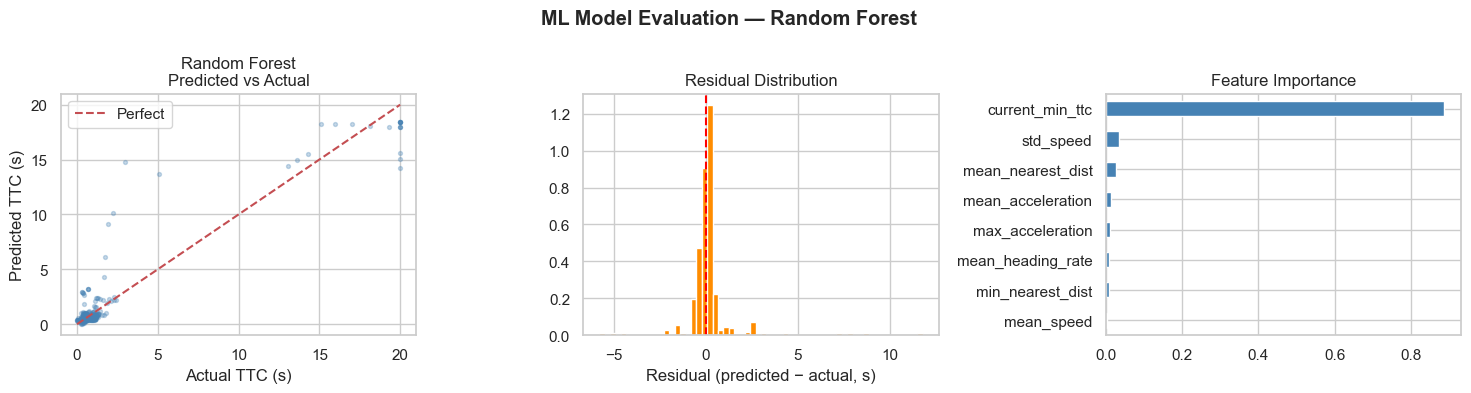

In [6]:
# Use best model for detailed evaluation
best = max(results, key=lambda r: r.r2)
print(f'Best model: {best.model_name} (R²={best.r2:.4f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs actual
axes[0].scatter(best.targets, best.predictions, s=8, alpha=0.3, color='steelblue')
lim = [min(best.targets.min(), best.predictions.min()),
       max(best.targets.max(), best.predictions.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual TTC (s)')
axes[0].set_ylabel('Predicted TTC (s)')
axes[0].set_title(f'{best.model_name}\nPredicted vs Actual')
axes[0].legend()

# Residuals
residuals = best.predictions - best.targets
axes[1].hist(residuals, bins=60, color='darkorange', edgecolor='white', density=True)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (predicted − actual, s)')
axes[1].set_title('Residual Distribution')

# Feature importance
if best.feature_importance is not None:
    best.feature_importance.head(8).sort_values().plot.barh(ax=axes[2], color='steelblue', edgecolor='white')
    axes[2].set_title('Feature Importance')

plt.suptitle(f'ML Model Evaluation — {best.model_name}', fontweight='bold')
plt.tight_layout()
plt.show()

Expected Calibration Error (ECE): 0.5111 s


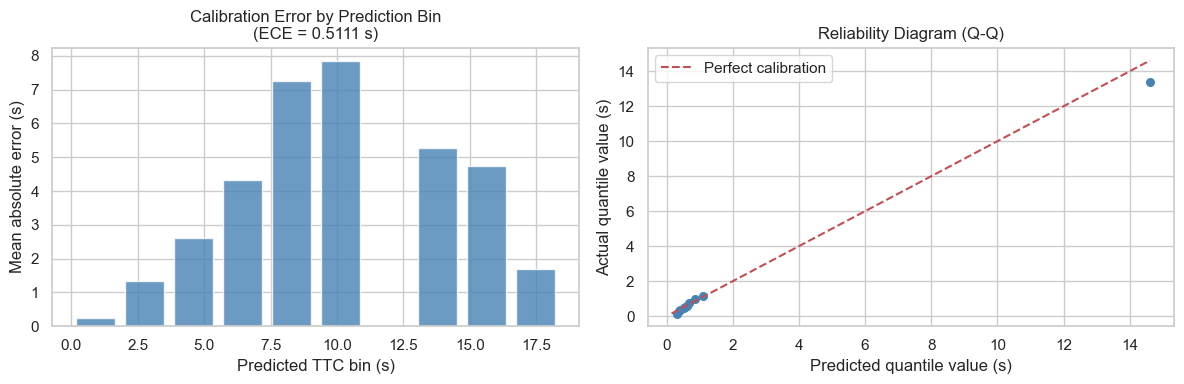

In [7]:
# Calibration: Expected Calibration Error
ece, bin_centers, bin_errors, bin_counts = expected_calibration_error(best.targets, best.predictions)
print(f'Expected Calibration Error (ECE): {ece:.4f} s')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ECE bar chart
axes[0].bar(bin_centers, bin_errors, width=(bin_centers[1]-bin_centers[0])*0.8,
            color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Predicted TTC bin (s)')
axes[0].set_ylabel('Mean absolute error (s)')
axes[0].set_title(f'Calibration Error by Prediction Bin\n(ECE = {ece:.4f} s)')

# Reliability diagram
rel = reliability_diagram_data(best.targets, best.predictions)
axes[1].scatter(rel['predicted_quantile_value'], rel['actual_quantile_value'],
                s=30, color='steelblue')
lim2 = [min(rel['predicted_quantile_value'].min(), rel['actual_quantile_value'].min()),
        max(rel['predicted_quantile_value'].max(), rel['actual_quantile_value'].max())]
axes[1].plot(lim2, lim2, 'r--', lw=1.5, label='Perfect calibration')
axes[1].set_xlabel('Predicted quantile value (s)')
axes[1].set_ylabel('Actual quantile value (s)')
axes[1].set_title('Reliability Diagram (Q-Q)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Error analysis
worst_frames = error_analysis(test_df, best.predictions)
print('Frames with largest prediction error:')
worst_frames[['segment_id', 'future_min_ttc', 'prediction', 'abs_error',
              'current_min_ttc', 'mean_speed', 'n_agents']].head(10)

Frames with largest prediction error:


,segment_id,future_min_ttc,prediction,abs_error,current_min_ttc,mean_speed,n_agents
982,10359308928573410754_720_000_740_000,2.962918,14.742062,11.779145,15.078684,0.364935,48
981,10359308928573410754_720_000_740_000,5.047172,13.718862,8.671690,15.992990,0.372153,47
983,10359308928573410754_720_000_740_000,2.249790,10.096715,7.846926,14.287244,0.365358,48
984,10359308928573410754_720_000_740_000,1.926558,9.174531,7.247972,13.620696,0.365830,48
961,10359308928573410754_720_000_740_000,20.000000,14.215041,5.784959,16.612696,0.237026,43
962,10359308928573410754_720_000_740_000,20.000000,15.058713,4.941287,17.895738,0.234497,43
963,10359308928573410754_720_000_740_000,20.000000,15.568006,4.431994,19.390599,0.222335,45
985,10359308928573410754_720_000_740_000,1.761696,6.089840,4.328144,13.075915,0.366321,48
977,10359308928573410754_720_000_740_000,15.078684,18.249706,3.171022,20.000000,0.203723,46
990,10359308928573410754_720_000_740_000,0.313444,2.939487,2.626043,1.761696,0.370706,48


## Part B — Traffic Flow Modeling

In [9]:
print('Estimating macroscopic traffic flow variables...')
flow_df = estimate_flow_variables(trajectories, cell_length_m=100.0, time_window_s=5.0)
print(f'Flow observations: {len(flow_df):,}')
print(flow_df[['density_veh_per_m', 'flow_veh_per_s', 'space_mean_speed_mps']].describe().round(4))

Estimating macroscopic traffic flow variables...


Flow observations: 49
       density_veh_per_m  flow_veh_per_s  space_mean_speed_mps
count            49.0000         49.0000               49.0000
mean              0.2140          0.3089                3.0226
std               0.1720          0.3381                5.3192
min               0.0038          0.0000                0.0000
25%               0.0950          0.0037                0.0322
50%               0.1812          0.1799                0.6199
75%               0.2925          0.5387                2.4070
max               0.6795          1.1630               19.7588


/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/traffic/flow_model.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds = group.groupby("object_id").apply(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/traffic/flow_model.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds = group.groupby("object_id").apply(
/Users/sachiniweerasekara/

In [10]:
# Fit Greenshields model
try:
    fd_greenshields = fit_fundamental_diagram(flow_df, model='greenshields')
    print('Greenshields model fit:')
    print(f'  Free-flow speed v_f = {fd_greenshields.v_free_flow:.2f} m/s  '
          f'({fd_greenshields.v_free_flow*3.6:.1f} km/h)')
    print(f'  Jam density k_j     = {fd_greenshields.k_jam:.6f} veh/m  '
          f'({fd_greenshields.k_jam*1000:.2f} veh/km)')
    print(f'  Capacity q_max      = {fd_greenshields.q_capacity:.4f} veh/s  '
          f'({fd_greenshields.q_capacity*3600:.0f} veh/h)')
    print(f'  R²                  = {fd_greenshields.r2:.4f}')
except Exception as e:
    print(f'Greenshields fit: {e}')
    fd_greenshields = None

Greenshields fit: Initial guess is outside of provided bounds


In [11]:
fig = plot_fundamental_diagram(flow_df, fd_fit=fd_greenshields)
plt.show()

/var/folders/jj/khf1rsjs76137181nr0hly600000gn/T/ipykernel_30571/365644459.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
# Traffic state classification
flow_classified = classify_traffic_state(flow_df, fd_fit=fd_greenshields)
state_counts = flow_classified['traffic_state'].value_counts()
print('Traffic state distribution:')
print(state_counts)

fig, ax = plt.subplots(figsize=(7, 4))
colors_map = {'free_flow': 'mediumseagreen', 'transitional': 'orange', 'congested': 'tomato'}
bars = ax.bar(state_counts.index, state_counts.values,
              color=[colors_map.get(s, 'gray') for s in state_counts.index],
              edgecolor='white')
ax.set_ylabel('Number of observations')
ax.set_title('Traffic State Classification (Greenshields)')
for bar, v in zip(bars, state_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Traffic state distribution:
traffic_state
congested       37
free_flow        9
transitional     3
Name: count, dtype: int64


/var/folders/jj/khf1rsjs76137181nr0hly600000gn/T/ipykernel_30571/528644077.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
